In [3]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit

# control vars - example
rseed = 8
M = 0.1
d = 3
m = M / (2 * (d - 1))
r = 5e-1
Ne = 1000
t = 20
sample_size = 20  # 1000

# Create demography using the modern API
demography = msprime.Demography()
demography.add_population(name="Pop0", initial_size=Ne)
demography.add_population(name="Pop1", initial_size=Ne)
demography.add_population(name="Pop2", initial_size=Ne)

# Set continuous migration (backwards in time)
# Migration from Pop0 to Pop1
demography.set_migration_rate(source=1, dest=0, rate=m)
# Migration from Pop2 to Pop1
demography.set_migration_rate(source=1, dest=2, rate=m)

# Add mass migration events (backwards in time)
demography.add_mass_migration(time=t, source="Pop1", dest="Pop0", proportion=0.2)
demography.add_mass_migration(time=t, source="Pop1", dest="Pop2", proportion=1.0)

# Run simulation using sim_ancestry (modern API)
ts = msprime.sim_ancestry(
    samples={"Pop1": sample_size},  # Only sample from Pop1 (the admixed population)
    demography=demography,
    sequence_length=1,  # Required in modern API (set to 1 for single locus)
    recombination_rate=r,
    ploidy=2,  # DTWF requires diploid individuals
    model="dtwf",  # discrete Wright-Fisher
    end_time=t+1,
    record_migrations=True,
    random_seed=rseed
)

tables = ts.dump_tables()
nodes = tables.nodes
edges = tables.edges
migrations = tables.migrations

# resolve ancestry - record children of migrated sample nodes
# Note: with ploidy=2, you now have 2*sample_size nodes (40 instead of 20)
num_sample_nodes = 2 * sample_size
z = migrations.node[migrations.node >= num_sample_nodes]  # take only non-sample nodes
if z.size > 0:
    linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))  # link ancestors to samples
else:
    linked_edges = tskit.EdgeTable()  # otherwise make an empty table

print(linked_edges)


╔══╤════╤═════╤══════╤═════╤════════╗
║id│left│right│parent│child│metadata║
╠══╪════╪═════╪══════╪═════╪════════╣
║0 │   0│    1│    40│   17│        ║
║1 │   0│    1│    40│   34│        ║
╚══╧════╧═════╧══════╧═════╧════════╝



Population 0 tracts: 16
Population 1 tracts: 0
Population 2 tracts: 24


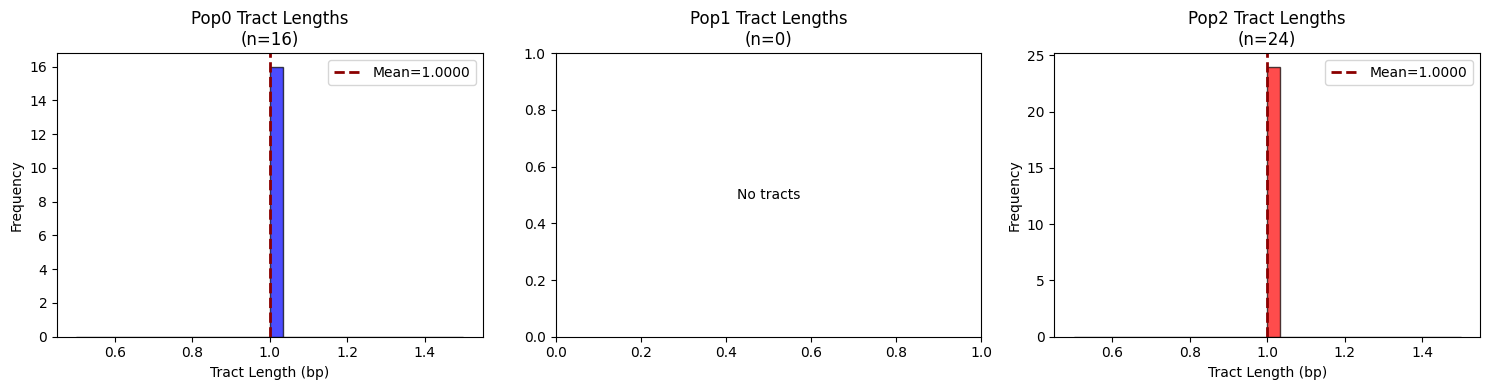

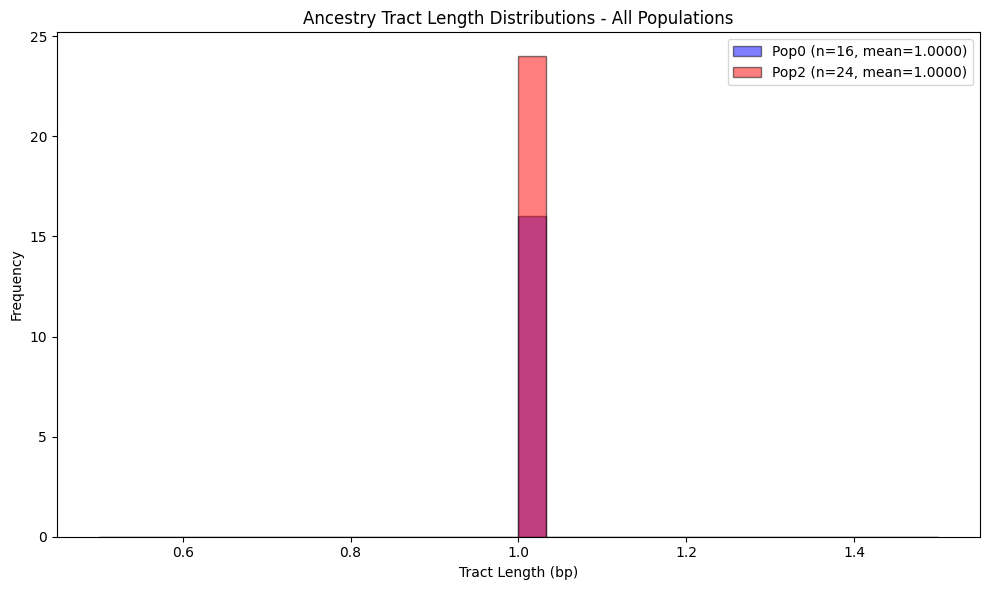

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit
from collections import defaultdict

# control vars - example
rseed = 8
M = 0.1
d = 3
m = M / (2 * (d - 1))
r = 5e-1
Ne = 1000
t = 20
sample_size = 20  # 1000

# Create demography using the modern API
demography = msprime.Demography()
demography.add_population(name="Pop0", initial_size=Ne)
demography.add_population(name="Pop1", initial_size=Ne)
demography.add_population(name="Pop2", initial_size=Ne)

# Set continuous migration (backwards in time)
demography.set_migration_rate(source=1, dest=0, rate=m)
demography.set_migration_rate(source=1, dest=2, rate=m)

# Add mass migration events (backwards in time)
demography.add_mass_migration(time=t, source="Pop1", dest="Pop0", proportion=0.2)
demography.add_mass_migration(time=t, source="Pop1", dest="Pop2", proportion=1.0)

# Run simulation using sim_ancestry (modern API)
ts = msprime.sim_ancestry(
    samples={"Pop1": sample_size},
    demography=demography,
    sequence_length=1,
    recombination_rate=r,
    ploidy=2,  # DTWF requires diploid individuals
    model="dtwf",
    end_time=t+1,
    record_migrations=True,
    random_seed=rseed
)

tables = ts.dump_tables()
nodes = tables.nodes
edges = tables.edges
migrations = tables.migrations

# Build cache of children for each node
num_sample_nodes = 2 * sample_size
z = migrations.node[migrations.node >= num_sample_nodes]

if z.size > 0:
    linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
else:
    linked_edges = tskit.EdgeTable()

# Build children cache
ch_cache = defaultdict(list)
for edge in linked_edges:
    ch_cache[edge.parent].append(edge)

# Extract tracts
tracts = [[], [], []]  # One list for each destination population

for row in migrations:
    if row.node < num_sample_nodes:  # sample migrates directly
        seg_length = row.right - row.left
        tracts[row.dest].append(seg_length)
    else:  # ancestor of the sample migrates
        children = ch_cache[row.node]
        for child in children:
            seg_length = child.right - child.left
            tracts[row.dest].append(seg_length)

# Print summary statistics
print(f"Population 0 tracts: {len(tracts[0])}")
print(f"Population 1 tracts: {len(tracts[1])}")
print(f"Population 2 tracts: {len(tracts[2])}")

# Plot the tract length distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pop_names = ['Pop0', 'Pop1', 'Pop2']
colors = ['blue', 'green', 'red']

for i, (tract_list, pop_name, color) in enumerate(zip(tracts, pop_names, colors)):
    if len(tract_list) > 0:
        axes[i].hist(tract_list, bins=30, alpha=0.7, color=color, edgecolor='black')
        axes[i].set_xlabel('Tract Length (bp)')
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'{pop_name} Tract Lengths\n(n={len(tract_list)})')
        axes[i].axvline(np.mean(tract_list), color='darkred', linestyle='--', 
                       linewidth=2, label=f'Mean={np.mean(tract_list):.4f}')
        axes[i].legend()
    else:
        axes[i].text(0.5, 0.5, 'No tracts', ha='center', va='center', 
                    transform=axes[i].transAxes)
        axes[i].set_title(f'{pop_name} Tract Lengths\n(n=0)')

plt.tight_layout()
plt.savefig('tract_length_distributions.png', dpi=300)
plt.show()

# Additional comparison plot: overlay all populations
plt.figure(figsize=(10, 6))
for i, (tract_list, pop_name, color) in enumerate(zip(tracts, pop_names, colors)):
    if len(tract_list) > 0:
        plt.hist(tract_list, bins=30, alpha=0.5, color=color, 
                label=f'{pop_name} (n={len(tract_list)}, mean={np.mean(tract_list):.4f})',
                edgecolor='black')

plt.xlabel('Tract Length (bp)')
plt.ylabel('Frequency')
plt.title('Ancestry Tract Length Distributions - All Populations')
plt.legend()
plt.tight_layout()
plt.savefig('tract_length_overlay.png', dpi=300)
plt.show()

Simulating...
Extracting tracts...
Number of Pop0 tracts: 1542
Mean tract length: 0.0824 Morgans


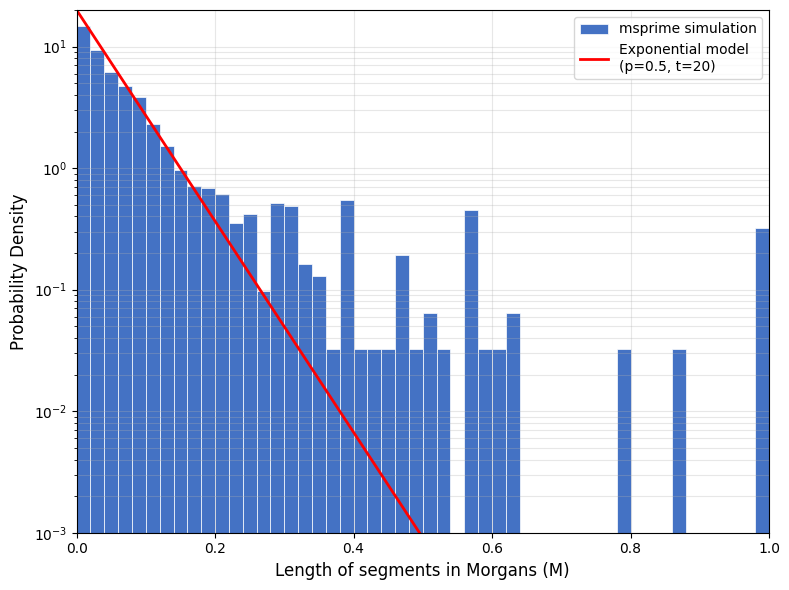

Plot saved as 'tract_length_exponential_comparison.png'


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit
from collections import defaultdict

# control vars - matching the figure parameters
rseed = 8
M = 0.1
d = 3
m = M / (2 * (d - 1))
r = 1e-8  # Changed to match figure: 1e-8 per bp per generation
Ne = 10000  # Starting with 10k for faster simulation
t = 20
sample_size = 100  # Increased sample size for better statistics
sequence_length = 1e8  # 100 Mb = 1 Morgan

# Create demography using the modern API
demography = msprime.Demography()
demography.add_population(name="Pop0", initial_size=Ne)
demography.add_population(name="Pop1", initial_size=Ne)
demography.add_population(name="Pop2", initial_size=Ne)

# Set continuous migration (backwards in time)
demography.set_migration_rate(source=1, dest=0, rate=m)
demography.set_migration_rate(source=1, dest=2, rate=m)

# Add mass migration events (backwards in time)
# Using 0.5 proportion to match p=0.5 in the figure
demography.add_mass_migration(time=t, source="Pop1", dest="Pop0", proportion=0.5)
demography.add_mass_migration(time=t, source="Pop1", dest="Pop2", proportion=1.0)

print("Simulating...")
# Run simulation using sim_ancestry (modern API)
ts = msprime.sim_ancestry(
    samples={"Pop1": sample_size},
    demography=demography,
    sequence_length=sequence_length,
    recombination_rate=r,
    ploidy=2,
    model="dtwf",
    end_time=t+1,
    record_migrations=True,
    random_seed=rseed
)

print("Extracting tracts...")
tables = ts.dump_tables()
nodes = tables.nodes
edges = tables.edges
migrations = tables.migrations

# Build cache of children for each node
num_sample_nodes = 2 * sample_size
z = migrations.node[migrations.node >= num_sample_nodes]

if z.size > 0:
    linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
else:
    linked_edges = tskit.EdgeTable()

# Build children cache
ch_cache = defaultdict(list)
for edge in linked_edges:
    ch_cache[edge.parent].append(edge)

# Extract tracts
tracts = [[], [], []]  # One list for each destination population

for row in migrations:
    if row.node < num_sample_nodes:  # sample migrates directly
        seg_length = row.right - row.left
        tracts[row.dest].append(seg_length)
    else:  # ancestor of the sample migrates
        children = ch_cache[row.node]
        for child in children:
            seg_length = child.right - child.left
            tracts[row.dest].append(seg_length)

# Convert to Morgans (divide by sequence_length which is 1e8 bp = 1 Morgan)
tracts_morgans = [np.array(t) / sequence_length for t in tracts]

# Focus on Pop0 tracts (analogous to the figure)
pop0_tracts = tracts_morgans[0]

print(f"Number of Pop0 tracts: {len(pop0_tracts)}")
print(f"Mean tract length: {np.mean(pop0_tracts):.4f} Morgans")

# Create the plot matching the figure style
fig, ax = plt.subplots(figsize=(8, 6))

# Histogram with 50 bins (as mentioned in the figure caption)
counts, bins, patches = ax.hist(pop0_tracts, bins=50, 
                                 color='#4472C4',  # Blue color
                                 edgecolor='white', 
                                 linewidth=0.5,
                                 density=True,  # Normalize to probability density
                                 label='msprime simulation')

# Exponential distribution overlay
# For exponential distribution of tract lengths: f(x) = t * exp(-t * x)
# where t is the number of generations
x = np.linspace(0, 1, 1000)
p = 0.5  # proportion of ancestry (matches figure)
exponential_density = t * np.exp(-t * x)

ax.plot(x, exponential_density, 'r-', linewidth=2, 
        label=f'Exponential model\n(p={p}, t={t})')

# Set log scale on y-axis
ax.set_yscale('log')
ax.set_ylim([1e-3, 20])  # Match the figure's y-axis range

# Labels and formatting
ax.set_xlabel('Length of segments in Morgans (M)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_xlim([0, 1])
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('tract_length_exponential_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'tract_length_exponential_comparison.png'")

Running simulations...
  Processing t=5, p=0.1...
  Processing t=5, p=0.25...
  Processing t=5, p=0.5...
  Processing t=20, p=0.1...
  Processing t=20, p=0.25...
  Processing t=20, p=0.5...
  Processing t=50, p=0.1...
  Processing t=50, p=0.25...
  Processing t=50, p=0.5...
  Processing t=80, p=0.1...
  Processing t=80, p=0.25...
  Processing t=80, p=0.5...

Plots saved!


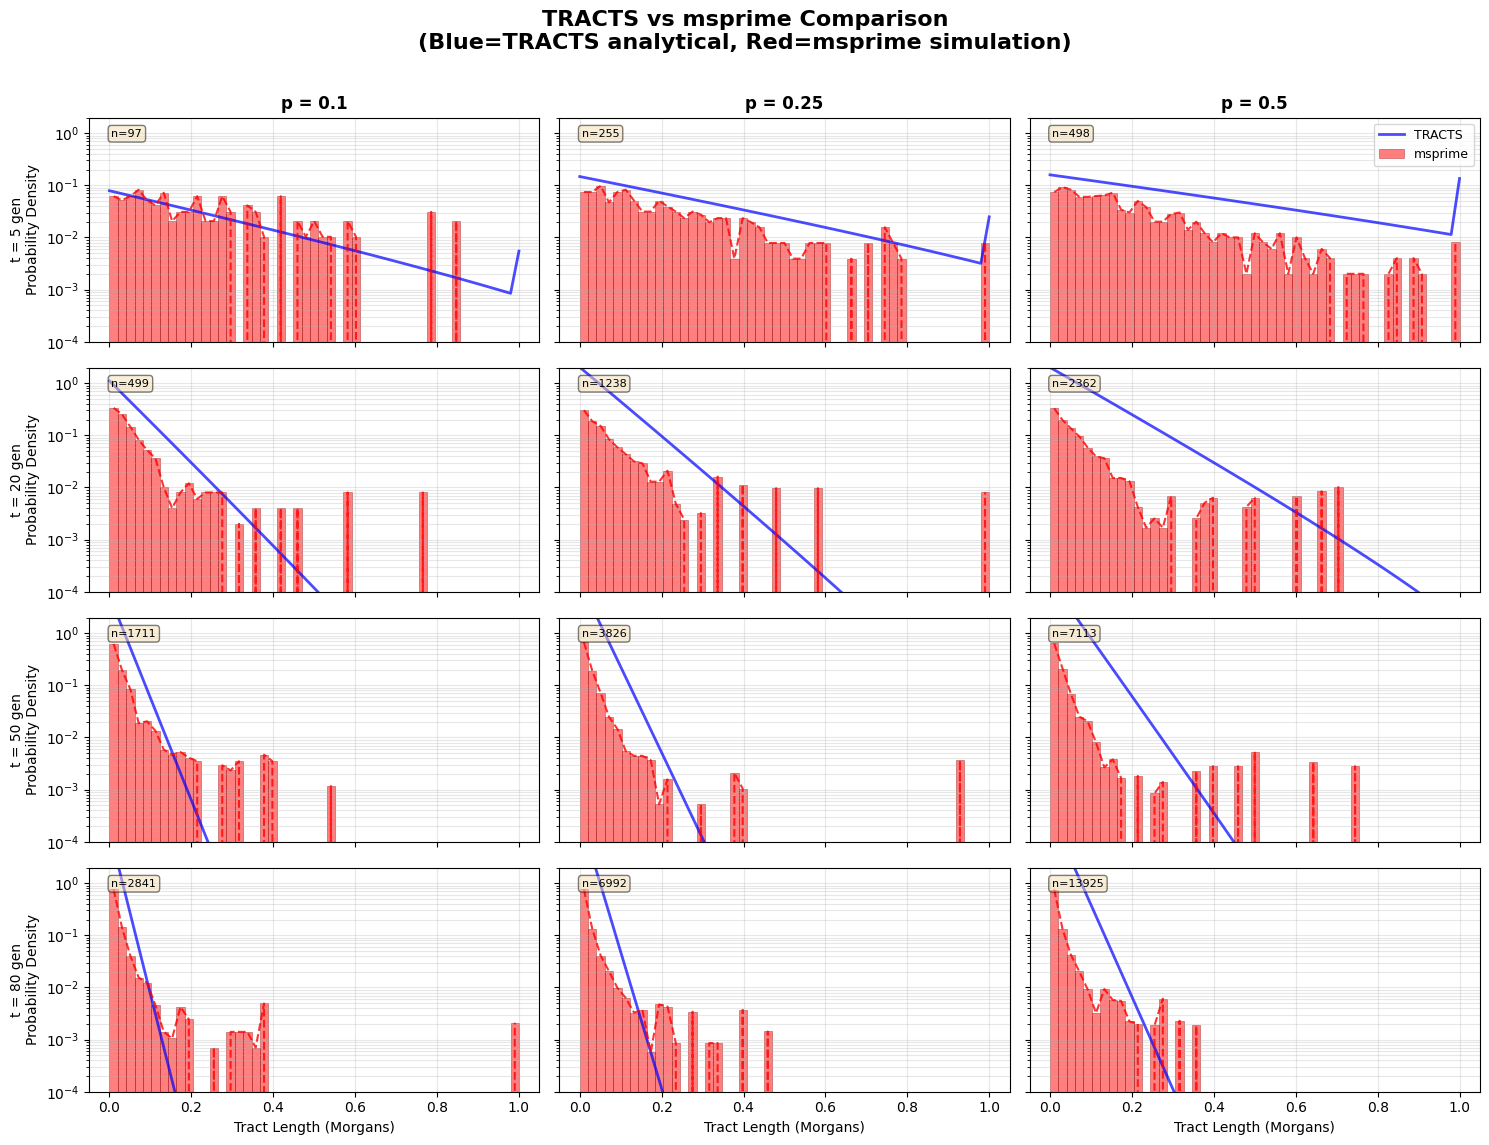


SUMMARY STATISTICS

t=5 gen, p=0.1:
  msprime: n=97, mean=0.2449 M
  Theoretical exponential mean: 0.2000 M


ValueError: operands could not be broadcast together with shapes (49,) (50,) 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit
from collections import defaultdict

# Try to import tracts - we'll handle if it's not available
try:
    import tracts
    HAS_TRACTS = True
except ImportError:
    HAS_TRACTS = False
    print("Warning: tracts not available, will only show msprime results")

# ============================================================================
# SHARED PARAMETERS
# ============================================================================
times = [5, 20, 50, 80]  # Admixture times in generations
props = [0.10, 0.25, 0.50]  # Pop0 ancestry proportions
sequence_length = 1e8  # 100 Mb = 1 Morgan
r = 1e-8  # Recombination rate
Ne = 10000  # Effective population size
sample_size = 100  # Number of diploid samples
bins = np.linspace(0, 1.0, 50)  # 50 bins from 0 to 1 Morgan
Ls = [1.0]  # 1 Morgan for TRACTS

# ============================================================================
# FUNCTION: RUN MSPRIME SIMULATION
# ============================================================================
def run_msprime_simulation(t, p, rseed=42):
    """Run msprime simulation and extract tract lengths in Morgans"""
    
    # Create demography
    demography = msprime.Demography()
    demography.add_population(name="Pop0", initial_size=Ne)
    demography.add_population(name="Pop1", initial_size=Ne)
    demography.add_population(name="Pop2", initial_size=Ne)
    
    # Add mass migration events (backwards in time)
    demography.add_mass_migration(time=t, source="Pop1", dest="Pop0", proportion=p)
    demography.add_mass_migration(time=t, source="Pop1", dest="Pop2", proportion=1.0)
    
    # Run simulation
    ts = msprime.sim_ancestry(
        samples={"Pop1": sample_size},
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=r,
        ploidy=2,
        model="dtwf",
        end_time=t+1,
        record_migrations=True,
        random_seed=rseed
    )
    
    # Extract tracts
    tables = ts.dump_tables()
    migrations = tables.migrations
    num_sample_nodes = 2 * sample_size
    
    # Build children cache
    z = migrations.node[migrations.node >= num_sample_nodes]
    if z.size > 0:
        linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
    else:
        linked_edges = tskit.EdgeTable()
    
    ch_cache = defaultdict(list)
    for edge in linked_edges:
        ch_cache[edge.parent].append(edge)
    
    # Extract tracts for each population
    tracts = [[], [], []]
    for row in migrations:
        if row.node < num_sample_nodes:
            seg_length = row.right - row.left
            tracts[row.dest].append(seg_length)
        else:
            children = ch_cache[row.node]
            for child in children:
                seg_length = child.right - child.left
                tracts[row.dest].append(seg_length)
    
    # Convert to Morgans
    tracts_morgans = [np.array(t) / sequence_length for t in tracts]
    
    return tracts_morgans[0]  # Return Pop0 tracts

# ============================================================================
# FUNCTION: RUN TRACTS MODEL
# ============================================================================
def run_tracts_model(t, p):
    """Run TRACTS demographic model"""
    if not HAS_TRACTS:
        return None
    
    # Build migration matrix (rows=generations, cols=populations)
    mig = np.zeros((t + 1, 2))
    mig[t, 0] = p
    mig[t, 1] = 1.0 - p
    
    # Create demographic model
    model = tracts.DemographicModel(mig)
    y = model.expectperbin(Ls, 0, bins)
    
    return y

# ============================================================================
# RUN ALL SIMULATIONS AND CREATE COMPARISON PLOT
# ============================================================================
print("Running simulations...")

fig, axes = plt.subplots(len(times), len(props), figsize=(15, 12), sharex=True, sharey=True)

for i, t in enumerate(times):
    for j, p in enumerate(props):
        print(f"  Processing t={t}, p={p}...")
        
        ax = axes[i, j]
        
        # Run TRACTS model
        if HAS_TRACTS:
            tracts_y = run_tracts_model(t, p)
            ax.plot(bins, tracts_y, 'b-', linewidth=2, label='TRACTS', alpha=0.7)
        
        # Run msprime simulation
        msprime_tracts = run_msprime_simulation(t, p, rseed=42+i*10+j)
        
        # Create histogram for msprime results
        counts, bin_edges = np.histogram(msprime_tracts, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        # Plot msprime as filled histogram
        ax.bar(bin_centers, counts * bin_width, width=bin_width, 
               alpha=0.5, color='red', edgecolor='darkred', 
               linewidth=0.5, label='msprime')
        
        # Also plot as line for easier comparison
        ax.plot(bin_centers, counts * bin_width, 'r--', 
                linewidth=1.5, alpha=0.8)
        
        # Formatting
        ax.set_yscale('log')
        ax.set_ylim([1e-4, 2])
        ax.grid(True, alpha=0.3, which='both')
        
        # Labels
        if i == 0:
            ax.set_title(f"p = {p}", fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f"t = {t} gen\nProbability Density", fontsize=10)
        if i == len(times)-1:
            ax.set_xlabel("Tract Length (Morgans)", fontsize=10)
        if i == 0 and j == len(props)-1:
            ax.legend(fontsize=9, loc='upper right')
        
        # Add text with number of msprime tracts
        ax.text(0.05, 0.95, f'n={len(msprime_tracts)}', 
                transform=ax.transAxes, fontsize=8,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("TRACTS vs msprime Comparison\n(Blue=TRACTS analytical, Red=msprime simulation)", 
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

# Save the plot
plt.savefig("TRACTS_vs_msprime_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("TRACTS_vs_msprime_comparison.pdf", bbox_inches='tight')
print("\nPlots saved!")

plt.show()

# ============================================================================
# PRINT SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

for i, t in enumerate(times):
    for j, p in enumerate(props):
        msprime_tracts = run_msprime_simulation(t, p, rseed=42+i*10+j)
        
        print(f"\nt={t} gen, p={p}:")
        print(f"  msprime: n={len(msprime_tracts)}, mean={np.mean(msprime_tracts):.4f} M")
        
        # Theoretical expectation for exponential: mean = 1/t
        theoretical_mean = 1.0 / t
        print(f"  Theoretical exponential mean: {theoretical_mean:.4f} M")
        
        if HAS_TRACTS:
            tracts_y = run_tracts_model(t, p)
            # Calculate mean from TRACTS distribution
            tracts_mean = np.sum(bins[:-1] * tracts_y) / np.sum(tracts_y)
            print(f"  TRACTS mean: {tracts_mean:.4f} M")

print("\n" + "="*80)

Running TRACTS 3-way model...
Running msprime 3-way simulation...
Extracting tracts...

Plots saved!


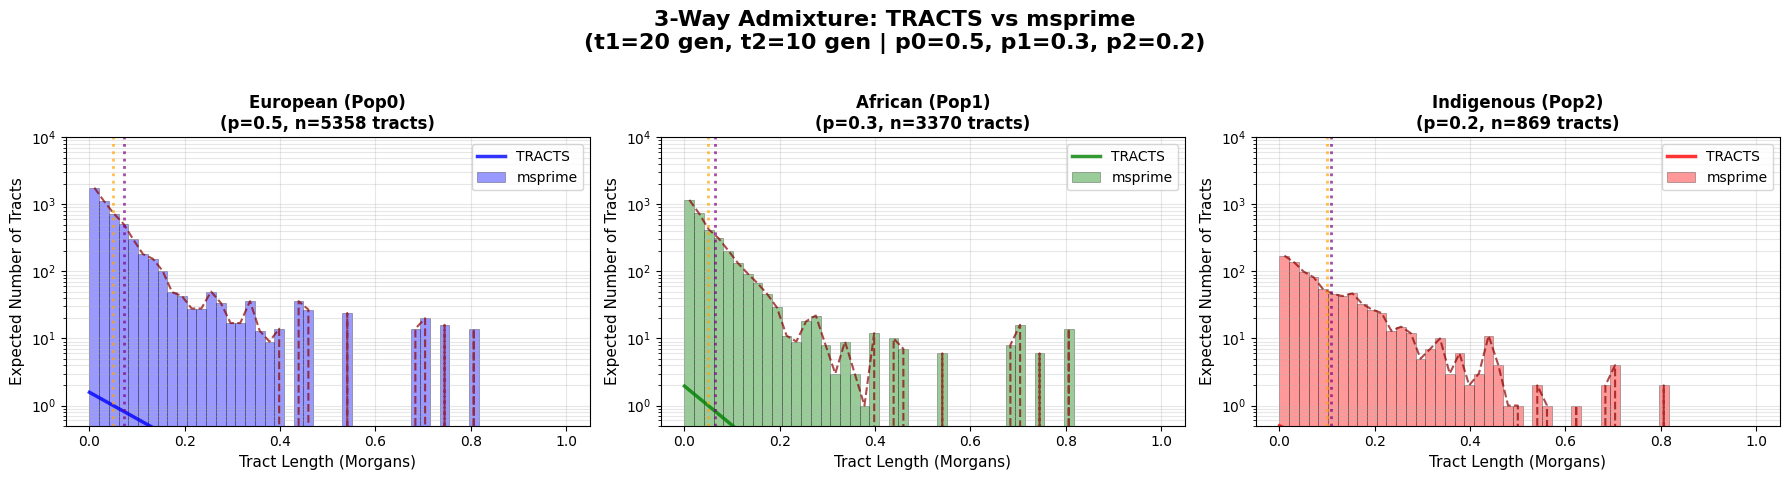


3-WAY ADMIXTURE SUMMARY

Parameters:
  t1 (initial admixture): 20 generations
  t2 (secondary admixture): 10 generations
  Target proportions: Pop0=0.5, Pop1=0.3, Pop2=0.2

European (Pop0):
  msprime: n=5358 tracts
  msprime mean: 0.0714 Morgans
  msprime median: 0.0363 Morgans
  Theoretical mean (1/20): 0.0500 Morgans

African (Pop1):
  msprime: n=3370 tracts
  msprime mean: 0.0641 Morgans
  msprime median: 0.0333 Morgans
  Theoretical mean (1/20): 0.0500 Morgans

Indigenous (Pop2):
  msprime: n=869 tracts
  msprime mean: 0.1077 Morgans
  msprime median: 0.0692 Morgans
  Theoretical mean (1/10): 0.1000 Morgans



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit
from collections import defaultdict

# Try to import tracts
try:
    import tracts
    HAS_TRACTS = True
except ImportError:
    HAS_TRACTS = False
    print("Warning: tracts not available")

# ============================================================================
# PARAMETERS - 3-way admixture (Latino/Colombian model)
# ============================================================================
t1, t2 = 20, 10  # Two admixture times
p0, p1, p2 = 0.5, 0.3, 0.2  # Final ancestry proportions

# msprime parameters
sequence_length = 1e8  # 100 Mb = 1 Morgan
r = 1e-8  # Recombination rate
Ne = 10000
sample_size = 200  # Increased for better statistics in 3-way
bins = np.linspace(0, 1, 50)
Ls = [1.0]

# ============================================================================
# TRACTS 3-WAY MODEL
# ============================================================================
def run_tracts_3way():
    """Run TRACTS 3-way admixture model"""
    if not HAS_TRACTS:
        return None, None, None
    
    # Create migration matrix for 3 populations
    mig_3way = np.zeros((t1 + 1, 3))
    
    # Initial pulse at generation 20 (Pop0 and Pop1)
    mig_3way[t1, 0] = 0.625  # Adjusted for final proportions
    mig_3way[t1, 1] = 0.375
    
    # Secondary pulse at generation 10 (Pop2 enters)
    mig_3way[t2, 2] = 0.2
    
    model_3way = tracts.DemographicModel(mig_3way)
    
    # Get expected tracts for each population
    y0 = model_3way.expectperbin(Ls, 0, bins)  # European
    y1 = model_3way.expectperbin(Ls, 1, bins)  # African
    y2 = model_3way.expectperbin(Ls, 2, bins)  # Indigenous
    
    return y0, y1, y2

# ============================================================================
# MSPRIME 3-WAY MODEL
# ============================================================================
def run_msprime_3way(rseed=42):
    """
    Run msprime 3-way admixture simulation
    
    Timeline (backward in time):
    - Present: Admixed population (Pop_Adm)
    - t2=10 gen ago: Pop2 (Indigenous) contributes 20%
    - t1=20 gen ago: Pop0 (European) and Pop1 (African) contribute to remaining
    """
    
    # Create demography with 4 populations
    demography = msprime.Demography()
    demography.add_population(name="Adm", initial_size=Ne)  # Admixed (present)
    demography.add_population(name="Pop0", initial_size=Ne)  # European
    demography.add_population(name="Pop1", initial_size=Ne)  # African
    demography.add_population(name="Pop2", initial_size=Ne)  # Indigenous
    
    # At t2=10 generations ago: Pop2 contributes 20%
    demography.add_mass_migration(time=t2, source="Adm", dest="Pop2", proportion=p2)
    
    # At t1=20 generations ago: remaining ancestry splits between Pop0 and Pop1
    # We want final proportions p0=0.5, p1=0.3 out of the remaining 0.8
    # So proportions at t1 should be: p0/(p0+p1) and p1/(p0+p1)
    prop_pop0_at_t1 = p0 / (p0 + p1)  # 0.5/0.8 = 0.625
    prop_pop1_at_t1 = p1 / (p0 + p1)  # 0.3/0.8 = 0.375
    
    demography.add_mass_migration(time=t1, source="Adm", dest="Pop0", proportion=prop_pop0_at_t1)
    demography.add_mass_migration(time=t1, source="Adm", dest="Pop1", proportion=1.0)
    
    print("Running msprime 3-way simulation...")
    
    # Run simulation
    ts = msprime.sim_ancestry(
        samples={"Adm": sample_size},
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=r,
        ploidy=2,
        model="dtwf",
        end_time=t1+1,
        record_migrations=True,
        random_seed=rseed
    )
    
    print("Extracting tracts...")
    
    # Extract tracts
    tables = ts.dump_tables()
    migrations = tables.migrations
    num_sample_nodes = 2 * sample_size
    
    # Build children cache
    z = migrations.node[migrations.node >= num_sample_nodes]
    if z.size > 0:
        linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
    else:
        linked_edges = tskit.EdgeTable()
    
    ch_cache = defaultdict(list)
    for edge in linked_edges:
        ch_cache[edge.parent].append(edge)
    
    # Extract tracts for each population (0=Adm, 1=Pop0, 2=Pop1, 3=Pop2)
    tracts = [[], [], [], []]
    for row in migrations:
        if row.node < num_sample_nodes:
            seg_length = row.right - row.left
            tracts[row.dest].append(seg_length)
        else:
            children = ch_cache[row.node]
            for child in children:
                seg_length = child.right - child.left
                tracts[row.dest].append(seg_length)
    
    # Convert to Morgans (indices: 1=Pop0, 2=Pop1, 3=Pop2)
    tracts_morgans = [np.array(t) / sequence_length for t in tracts]
    
    return tracts_morgans[1], tracts_morgans[2], tracts_morgans[3]

# ============================================================================
# RUN BOTH MODELS AND CREATE COMPARISON
# ============================================================================

# Run TRACTS
if HAS_TRACTS:
    print("Running TRACTS 3-way model...")
    tracts_y0, tracts_y1, tracts_y2 = run_tracts_3way()
else:
    tracts_y0, tracts_y1, tracts_y2 = None, None, None

# Run msprime
msprime_pop0, msprime_pop1, msprime_pop2 = run_msprime_3way(rseed=42)

# ============================================================================
# CREATE COMPARISON PLOT
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pop_labels = ['European (Pop0)', 'African (Pop1)', 'Indigenous (Pop2)']
colors = ['blue', 'green', 'red']
msprime_data = [msprime_pop0, msprime_pop1, msprime_pop2]
tracts_data = [tracts_y0, tracts_y1, tracts_y2]
final_props = [p0, p1, p2]

for idx, (ax, label, color, msp_tracts, tr_y, prop) in enumerate(
    zip(axes, pop_labels, colors, msprime_data, tracts_data, final_props)):
    
    # Plot TRACTS
    if HAS_TRACTS and tr_y is not None:
        ax.plot(bins, tr_y, color=color, linewidth=2.5, 
                label='TRACTS', alpha=0.8, linestyle='-')
    
    # Plot msprime histogram
    if len(msp_tracts) > 0:
        counts, bin_edges = np.histogram(msp_tracts, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        # Filled histogram
        ax.bar(bin_centers, counts, width=bin_width, 
               alpha=0.4, color=color, edgecolor='black', 
               linewidth=0.5, label='msprime')
        
        # Line overlay
        ax.plot(bin_centers, counts, color='darkred', 
                linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Formatting
    ax.set_yscale('log')
    ax.set_ylim([0.5, 1e4])
    ax.set_xlabel('Tract Length (Morgans)', fontsize=11)
    ax.set_ylabel('Expected Number of Tracts', fontsize=11)
    ax.set_title(f'{label}\n(p={prop}, n={len(msp_tracts)} tracts)', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=10)
    
    # Add theoretical mean
    if idx == 0:
        # Pop0: only affected by t1
        theoretical_mean = 1.0 / t1
    elif idx == 1:
        # Pop1: only affected by t1
        theoretical_mean = 1.0 / t1
    else:
        # Pop2: only affected by t2
        theoretical_mean = 1.0 / t2
    
    if len(msp_tracts) > 0:
        ax.axvline(np.mean(msp_tracts), color='purple', linestyle=':', 
                   linewidth=2, alpha=0.7, 
                   label=f'msprime mean={np.mean(msp_tracts):.4f}')
        ax.axvline(theoretical_mean, color='orange', linestyle=':', 
                   linewidth=2, alpha=0.7,
                   label=f'theory mean={theoretical_mean:.4f}')

plt.suptitle('3-Way Admixture: TRACTS vs msprime\n' + 
             f'(t1={t1} gen, t2={t2} gen | p0={p0}, p1={p1}, p2={p2})',
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

# Save
plt.savefig("3way_admixture_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("3way_admixture_comparison.pdf", bbox_inches='tight')
print("\nPlots saved!")

plt.show()

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("3-WAY ADMIXTURE SUMMARY")
print("="*80)
print(f"\nParameters:")
print(f"  t1 (initial admixture): {t1} generations")
print(f"  t2 (secondary admixture): {t2} generations")
print(f"  Target proportions: Pop0={p0}, Pop1={p1}, Pop2={p2}")

for idx, (label, msp_tracts) in enumerate(zip(pop_labels, msprime_data)):
    print(f"\n{label}:")
    print(f"  msprime: n={len(msp_tracts)} tracts")
    if len(msp_tracts) > 0:
        print(f"  msprime mean: {np.mean(msp_tracts):.4f} Morgans")
        print(f"  msprime median: {np.median(msp_tracts):.4f} Morgans")
    
    # Theoretical expectation
    if idx in [0, 1]:  # Pop0 and Pop1 affected by t1
        theory_mean = 1.0 / t1
        print(f"  Theoretical mean (1/{t1}): {theory_mean:.4f} Morgans")
    else:  # Pop2 affected by t2
        theory_mean = 1.0 / t2
        print(f"  Theoretical mean (1/{t2}): {theory_mean:.4f} Morgans")

print("\n" + "="*80)

Running TRACTS 3-way model...
TRACTS raw output shapes: y0=(50,), y1=(50,), y2=(50,)
After flattening: y0=(50,), y1=(50,), y2=(50,)
Trimmed to bin size: y0=(49,), y1=(49,), y2=(49,)
TRACTS scaled for 400 haploid chromosomes
Final shapes: y0=(49,), y1=(49,), y2=(49,)
Running msprime 3-way simulation...
Extracting tracts...

Plots saved!


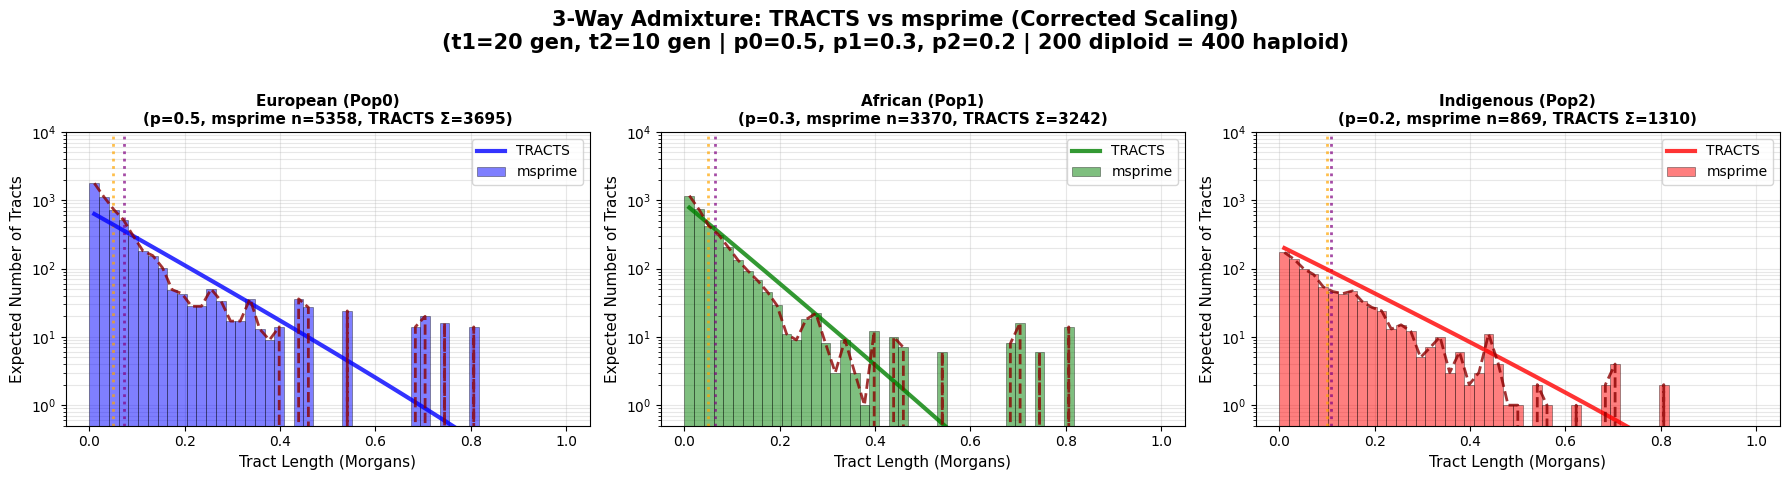


3-WAY ADMIXTURE SUMMARY (CORRECTED)

Parameters:
  t1 (initial admixture): 20 generations
  t2 (secondary admixture): 10 generations
  Target proportions: Pop0=0.5, Pop1=0.3, Pop2=0.2
  Sample size: 200 diploid individuals = 400 haploid chromosomes

European (Pop0):
  msprime: n=5358 tracts
  TRACTS: Σ=3695 expected tracts
  Ratio (TRACTS/msprime): 0.69
  msprime mean: 0.0714 Morgans
  msprime median: 0.0363 Morgans
  Theoretical mean (1/20): 0.0500 Morgans

African (Pop1):
  msprime: n=3370 tracts
  TRACTS: Σ=3242 expected tracts
  Ratio (TRACTS/msprime): 0.96
  msprime mean: 0.0641 Morgans
  msprime median: 0.0333 Morgans
  Theoretical mean (1/20): 0.0500 Morgans

Indigenous (Pop2):
  msprime: n=869 tracts
  TRACTS: Σ=1310 expected tracts
  Ratio (TRACTS/msprime): 1.51
  msprime mean: 0.1077 Morgans
  msprime median: 0.0692 Morgans
  Theoretical mean (1/10): 0.1000 Morgans



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit
from collections import defaultdict

# Try to import tracts
try:
    import tracts
    HAS_TRACTS = True
except ImportError:
    HAS_TRACTS = False
    print("Warning: tracts not available")

# ============================================================================
# PARAMETERS - 3-way admixture (Latino/Colombian model)
# ============================================================================
t1, t2 = 20, 10  # Two admixture times
p0, p1, p2 = 0.5, 0.3, 0.2  # Final ancestry proportions

# msprime parameters
sequence_length = 1e8  # 100 Mb = 1 Morgan
r = 1e-8  # Recombination rate
Ne = 10000
sample_size = 200  # Number of DIPLOID individuals
bins = np.linspace(0, 1, 50)
Ls = [1.0]

# ============================================================================
# TRACTS 3-WAY MODEL
# ============================================================================
def run_tracts_3way():
    """Run TRACTS 3-way admixture model"""
    if not HAS_TRACTS:
        return None, None, None
    
    # Create migration matrix for 3 populations
    mig_3way = np.zeros((t1 + 1, 3))
    
    # Initial pulse at generation 20 (Pop0 and Pop1)
    mig_3way[t1, 0] = 0.625  # Adjusted for final proportions
    mig_3way[t1, 1] = 0.375
    
    # Secondary pulse at generation 10 (Pop2 enters)
    mig_3way[t2, 2] = 0.2
    
    model_3way = tracts.DemographicModel(mig_3way)
    
    # Get expected tracts for each population
    # TRACTS returns expected tracts per HAPLOID genome
    y0_raw = model_3way.expectperbin(Ls, 0, bins)  # European
    y1_raw = model_3way.expectperbin(Ls, 1, bins)  # African
    y2_raw = model_3way.expectperbin(Ls, 2, bins)  # Indigenous
    
    # Debug: check what we got
    print(f"TRACTS raw output shapes: y0={np.array(y0_raw).shape}, y1={np.array(y1_raw).shape}, y2={np.array(y2_raw).shape}")
    
    # TRACTS expectperbin might return nested arrays - flatten if needed
    y0 = np.array(y0_raw).flatten()
    y1 = np.array(y1_raw).flatten()
    y2 = np.array(y2_raw).flatten()
    
    print(f"After flattening: y0={y0.shape}, y1={y1.shape}, y2={y2.shape}")
    
    # The output should match bins (length 50), but if it's returning something else
    # we need to handle it properly
    # expectperbin should give us values for each bin, so take the first len(bins)-1 elements
    if len(y0) > len(bins) - 1:
        y0 = y0[:len(bins)-1]
        y1 = y1[:len(bins)-1]
        y2 = y2[:len(bins)-1]
        print(f"Trimmed to bin size: y0={y0.shape}, y1={y1.shape}, y2={y2.shape}")
    
    # CRITICAL: Scale by number of haploid chromosomes
    # We have sample_size DIPLOID individuals = 2*sample_size haploid chromosomes
    scaling_factor = 2 * sample_size
    
    y0_scaled = y0 * scaling_factor
    y1_scaled = y1 * scaling_factor
    y2_scaled = y2 * scaling_factor
    
    return y0_scaled, y1_scaled, y2_scaled

# ============================================================================
# MSPRIME 3-WAY MODEL
# ============================================================================
def run_msprime_3way(rseed=42):
    """
    Run msprime 3-way admixture simulation
    
    Timeline (backward in time):
    - Present: Admixed population (Pop_Adm)
    - t2=10 gen ago: Pop2 (Indigenous) contributes 20%
    - t1=20 gen ago: Pop0 (European) and Pop1 (African) contribute to remaining
    """
    
    # Create demography with 4 populations
    demography = msprime.Demography()
    demography.add_population(name="Adm", initial_size=Ne)  # Admixed (present)
    demography.add_population(name="Pop0", initial_size=Ne)  # European
    demography.add_population(name="Pop1", initial_size=Ne)  # African
    demography.add_population(name="Pop2", initial_size=Ne)  # Indigenous
    
    # At t2=10 generations ago: Pop2 contributes 20%
    demography.add_mass_migration(time=t2, source="Adm", dest="Pop2", proportion=p2)
    
    # At t1=20 generations ago: remaining ancestry splits between Pop0 and Pop1
    # We want final proportions p0=0.5, p1=0.3 out of the remaining 0.8
    # So proportions at t1 should be: p0/(p0+p1) and p1/(p0+p1)
    prop_pop0_at_t1 = p0 / (p0 + p1)  # 0.5/0.8 = 0.625
    prop_pop1_at_t1 = p1 / (p0 + p1)  # 0.3/0.8 = 0.375
    
    demography.add_mass_migration(time=t1, source="Adm", dest="Pop0", proportion=prop_pop0_at_t1)
    demography.add_mass_migration(time=t1, source="Adm", dest="Pop1", proportion=1.0)
    
    print("Running msprime 3-way simulation...")
    
    # Run simulation
    ts = msprime.sim_ancestry(
        samples={"Adm": sample_size},
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=r,
        ploidy=2,
        model="dtwf",
        end_time=t1+1,
        record_migrations=True,
        random_seed=rseed
    )
    
    print("Extracting tracts...")
    
    # Extract tracts
    tables = ts.dump_tables()
    migrations = tables.migrations
    num_sample_nodes = 2 * sample_size
    
    # Build children cache
    z = migrations.node[migrations.node >= num_sample_nodes]
    if z.size > 0:
        linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
    else:
        linked_edges = tskit.EdgeTable()
    
    ch_cache = defaultdict(list)
    for edge in linked_edges:
        ch_cache[edge.parent].append(edge)
    
    # Extract tracts for each population (0=Adm, 1=Pop0, 2=Pop1, 3=Pop2)
    tracts = [[], [], [], []]
    for row in migrations:
        if row.node < num_sample_nodes:
            seg_length = row.right - row.left
            tracts[row.dest].append(seg_length)
        else:
            children = ch_cache[row.node]
            for child in children:
                seg_length = child.right - child.left
                tracts[row.dest].append(seg_length)
    
    # Convert to Morgans (indices: 1=Pop0, 2=Pop1, 3=Pop2)
    tracts_morgans = [np.array(t) / sequence_length for t in tracts]
    
    return tracts_morgans[1], tracts_morgans[2], tracts_morgans[3]

# ============================================================================
# RUN BOTH MODELS AND CREATE COMPARISON
# ============================================================================

# Run TRACTS (now with proper scaling)
if HAS_TRACTS:
    print("Running TRACTS 3-way model...")
    tracts_y0, tracts_y1, tracts_y2 = run_tracts_3way()
    print(f"TRACTS scaled for {2*sample_size} haploid chromosomes")
    print(f"Final shapes: y0={tracts_y0.shape}, y1={tracts_y1.shape}, y2={tracts_y2.shape}")
else:
    tracts_y0, tracts_y1, tracts_y2 = None, None, None

# Run msprime
msprime_pop0, msprime_pop1, msprime_pop2 = run_msprime_3way(rseed=42)

# ============================================================================
# CREATE COMPARISON PLOT
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pop_labels = ['European (Pop0)', 'African (Pop1)', 'Indigenous (Pop2)']
colors = ['blue', 'green', 'red']
msprime_data = [msprime_pop0, msprime_pop1, msprime_pop2]
tracts_data = [tracts_y0, tracts_y1, tracts_y2]
final_props = [p0, p1, p2]

for idx, (ax, label, color, msp_tracts, tr_y, prop) in enumerate(
    zip(axes, pop_labels, colors, msprime_data, tracts_data, final_props)):
    
    # Plot msprime histogram first
    if len(msp_tracts) > 0:
        counts, bin_edges = np.histogram(msp_tracts, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        # Filled histogram
        ax.bar(bin_centers, counts, width=bin_width, 
               alpha=0.5, color=color, edgecolor='black', 
               linewidth=0.5, label='msprime', zorder=2)
        
        # Line overlay
        ax.plot(bin_centers, counts, color='darkred', 
                linestyle='--', linewidth=2, alpha=0.8, zorder=4)
    
    # Plot TRACTS (now properly scaled)
    if HAS_TRACTS and tr_y is not None:
        # Use bin centers (same as msprime) for x-axis
        bin_centers = (bins[:-1] + bins[1:]) / 2
        ax.plot(bin_centers, tr_y, color=color, linewidth=3, 
                label='TRACTS', alpha=0.8, linestyle='-', zorder=3)
    
    # Formatting
    ax.set_yscale('log')
    ax.set_ylim([0.5, 1e4])
    ax.set_xlabel('Tract Length (Morgans)', fontsize=11)
    ax.set_ylabel('Expected Number of Tracts', fontsize=11)
    
    # Updated title with both counts
    if HAS_TRACTS and tr_y is not None:
        title_str = f'{label}\n(p={prop}, msprime n={len(msp_tracts)}, TRACTS Σ={np.sum(tr_y):.0f})'
    else:
        title_str = f'{label}\n(p={prop}, n={len(msp_tracts)} tracts)'
    ax.set_title(title_str, fontsize=11, fontweight='bold')
    
    ax.grid(True, alpha=0.3, which='both', zorder=1)
    ax.legend(fontsize=10, loc='upper right')
    
    # Add theoretical mean
    if idx in [0, 1]:  # Pop0 and Pop1 affected by t1
        theoretical_mean = 1.0 / t1
    else:  # Pop2 affected by t2
        theoretical_mean = 1.0 / t2
    
    if len(msp_tracts) > 0:
        ax.axvline(np.mean(msp_tracts), color='purple', linestyle=':', 
                   linewidth=2, alpha=0.7, 
                   label=f'msprime μ={np.mean(msp_tracts):.3f}')
        ax.axvline(theoretical_mean, color='orange', linestyle=':', 
                   linewidth=2, alpha=0.7,
                   label=f'theory μ={theoretical_mean:.3f}')

plt.suptitle('3-Way Admixture: TRACTS vs msprime (Corrected Scaling)\n' + 
             f'(t1={t1} gen, t2={t2} gen | p0={p0}, p1={p1}, p2={p2} | {sample_size} diploid = {2*sample_size} haploid)',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

# Save
plt.savefig("3way_admixture_comparison_CORRECTED.png", dpi=300, bbox_inches='tight')
plt.savefig("3way_admixture_comparison_CORRECTED.pdf", bbox_inches='tight')
print("\nPlots saved!")

plt.show()

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("3-WAY ADMIXTURE SUMMARY (CORRECTED)")
print("="*80)
print(f"\nParameters:")
print(f"  t1 (initial admixture): {t1} generations")
print(f"  t2 (secondary admixture): {t2} generations")
print(f"  Target proportions: Pop0={p0}, Pop1={p1}, Pop2={p2}")
print(f"  Sample size: {sample_size} diploid individuals = {2*sample_size} haploid chromosomes")

for idx, (label, msp_tracts, tr_y) in enumerate(zip(pop_labels, msprime_data, 
                                                      [tracts_y0, tracts_y1, tracts_y2] if HAS_TRACTS else [None]*3)):
    print(f"\n{label}:")
    print(f"  msprime: n={len(msp_tracts)} tracts")
    if HAS_TRACTS and tr_y is not None:
        print(f"  TRACTS: Σ={np.sum(tr_y):.0f} expected tracts")
        if len(msp_tracts) > 0:
            print(f"  Ratio (TRACTS/msprime): {np.sum(tr_y)/len(msp_tracts):.2f}")
    
    if len(msp_tracts) > 0:
        print(f"  msprime mean: {np.mean(msp_tracts):.4f} Morgans")
        print(f"  msprime median: {np.median(msp_tracts):.4f} Morgans")
    
    # Theoretical expectation
    if idx in [0, 1]:  # Pop0 and Pop1 affected by t1
        theory_mean = 1.0 / t1
        print(f"  Theoretical mean (1/{t1}): {theory_mean:.4f} Morgans")
    else:  # Pop2 affected by t2
        theory_mean = 1.0 / t2
        print(f"  Theoretical mean (1/{t2}): {theory_mean:.4f} Morgans")

print("\n" + "="*80)

Running TRACTS multiple-wave model...
Running msprime multiple-wave simulation...
Extracting tracts...

Multiple-wave plots saved!


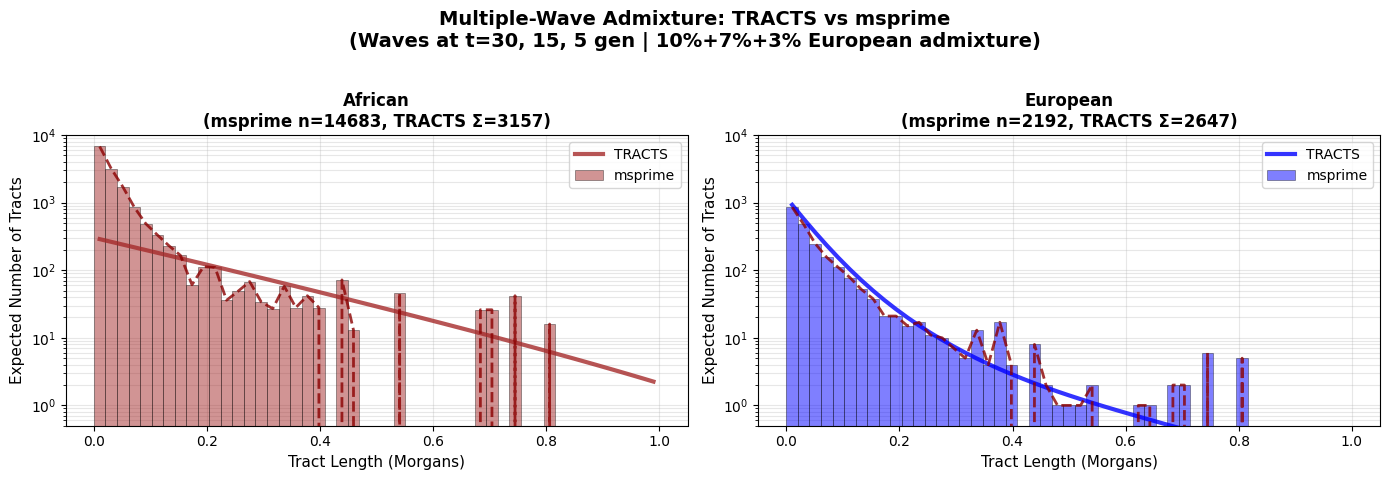


MULTIPLE-WAVE ADMIXTURE SUMMARY
Three admixture waves at t=30, 15, 5 generations
Wave 1 (t=30): 90% African, 10% European (founding)
Wave 2 (t=15): +7% European
Wave 3 (t=5): +3% European
Final expected: ~80% African, ~20% European

African ancestry:
  msprime: n=14683, mean=0.0512 M
  TRACTS: Σ=3157

European ancestry:
  msprime: n=2192, mean=0.0609 M
  TRACTS: Σ=2647


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit
from collections import defaultdict

# Try to import tracts
try:
    import tracts
    HAS_TRACTS = True
except ImportError:
    HAS_TRACTS = False
    print("Warning: tracts not available")

# ============================================================================
# SCENARIO 1: MULTIPLE-WAVE ADMIXTURE (CORRECTED)
# Example: African American history with multiple European admixture events
# ============================================================================

# Parameters
t1, t2, t3 = 30, 15, 5  # Three admixture waves (30, 15, 5 generations ago)

sequence_length = 1e8  # 100 Mb = 1 Morgan
r = 1e-8
Ne = 10000
sample_size = 200
bins = np.linspace(0, 1, 50)
Ls = [1.0]

# ============================================================================
# TRACTS: MULTIPLE-WAVE MODEL (CORRECTED)
# ============================================================================
def run_tracts_multiwave():
    """Run TRACTS multiple-wave admixture model"""
    if not HAS_TRACTS:
        return None, None
    
    # TRACTS requires the founding migration (oldest event) to sum to 1.0
    # Create migration matrix
    mig = np.zeros((t1 + 1, 2))  # 2 populations: African (0), European (1)
    
    # FOUNDING EVENT at t1=30 gen: must sum to 1.0
    # Start with 90% African, 10% European
    mig[t1, 0] = 0.90  # African
    mig[t1, 1] = 0.10  # European
    
    # Wave 2 at t2=15 gen: additional 7% European
    mig[t2, 1] = 0.07
    
    # Wave 3 at t3=5 gen: additional 3% European
    mig[t3, 1] = 0.03
    
    model = tracts.DemographicModel(mig)
    
    # Get expected tracts
    y_african = model.expectperbin(Ls, 0, bins)
    y_european = model.expectperbin(Ls, 1, bins)
    
    # Flatten and scale
    y_african = np.array(y_african).flatten()[:len(bins)-1]
    y_european = np.array(y_european).flatten()[:len(bins)-1]
    
    scaling_factor = 2 * sample_size
    y_african_scaled = y_african * scaling_factor
    y_european_scaled = y_european * scaling_factor
    
    return y_african_scaled, y_european_scaled

# ============================================================================
# MSPRIME: MULTIPLE-WAVE MODEL
# ============================================================================
def run_msprime_multiwave(rseed=42):
    """Run msprime multiple-wave admixture simulation"""
    
    demography = msprime.Demography()
    demography.add_population(name="Adm", initial_size=Ne)
    demography.add_population(name="African", initial_size=Ne)
    demography.add_population(name="European", initial_size=Ne)
    
    # Wave 3 (most recent): 3% European at t3=5 gen
    demography.add_mass_migration(time=t3, source="Adm", dest="European", proportion=0.03)
    
    # Wave 2: 7% European at t2=15 gen
    demography.add_mass_migration(time=t2, source="Adm", dest="European", proportion=0.07)
    
    # Wave 1 (oldest/founding): 10% European at t1=30 gen, rest to African
    demography.add_mass_migration(time=t1, source="Adm", dest="European", proportion=0.10)
    demography.add_mass_migration(time=t1, source="Adm", dest="African", proportion=1.0)
    
    print("Running msprime multiple-wave simulation...")
    
    ts = msprime.sim_ancestry(
        samples={"Adm": sample_size},
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=r,
        ploidy=2,
        model="dtwf",
        end_time=t1+1,
        record_migrations=True,
        random_seed=rseed
    )
    
    print("Extracting tracts...")
    
    tables = ts.dump_tables()
    migrations = tables.migrations
    num_sample_nodes = 2 * sample_size
    
    z = migrations.node[migrations.node >= num_sample_nodes]
    if z.size > 0:
        linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
    else:
        linked_edges = tskit.EdgeTable()
    
    ch_cache = defaultdict(list)
    for edge in linked_edges:
        ch_cache[edge.parent].append(edge)
    
    tracts = [[], [], []]  # 0=Adm, 1=African, 2=European
    for row in migrations:
        if row.node < num_sample_nodes:
            seg_length = row.right - row.left
            tracts[row.dest].append(seg_length)
        else:
            children = ch_cache[row.node]
            for child in children:
                seg_length = child.right - child.left
                tracts[row.dest].append(seg_length)
    
    tracts_morgans = [np.array(t) / sequence_length for t in tracts]
    
    return tracts_morgans[1], tracts_morgans[2]  # African, European

# ============================================================================
# RUN AND PLOT MULTIPLE-WAVE
# ============================================================================

if HAS_TRACTS:
    print("Running TRACTS multiple-wave model...")
    tracts_african, tracts_european = run_tracts_multiwave()
else:
    tracts_african, tracts_european = None, None

msprime_african, msprime_european = run_msprime_multiwave(rseed=42)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pop_labels = ['African', 'European']
colors = ['brown', 'blue']
msprime_data = [msprime_african, msprime_european]
tracts_data = [tracts_african, tracts_european]

for idx, (ax, label, color, msp_tracts, tr_y) in enumerate(
    zip(axes, pop_labels, colors, msprime_data, tracts_data)):
    
    # msprime histogram
    if len(msp_tracts) > 0:
        counts, bin_edges = np.histogram(msp_tracts, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        ax.bar(bin_centers, counts, width=bin_width, 
               alpha=0.5, color=color, edgecolor='black', 
               linewidth=0.5, label='msprime', zorder=2)
        ax.plot(bin_centers, counts, color='darkred', 
                linestyle='--', linewidth=2, alpha=0.8, zorder=4)
    
    # TRACTS
    if HAS_TRACTS and tr_y is not None:
        bin_centers = (bins[:-1] + bins[1:]) / 2
        ax.plot(bin_centers, tr_y, color=color, linewidth=3, 
                label='TRACTS', alpha=0.8, linestyle='-', zorder=3)
    
    ax.set_yscale('log')
    ax.set_ylim([0.5, 1e4])
    ax.set_xlabel('Tract Length (Morgans)', fontsize=11)
    ax.set_ylabel('Expected Number of Tracts', fontsize=11)
    
    if HAS_TRACTS and tr_y is not None:
        title_str = f'{label}\n(msprime n={len(msp_tracts)}, TRACTS Σ={np.sum(tr_y):.0f})'
    else:
        title_str = f'{label}\n(n={len(msp_tracts)} tracts)'
    ax.set_title(title_str, fontsize=12, fontweight='bold')
    
    ax.grid(True, alpha=0.3, which='both', zorder=1)
    ax.legend(fontsize=10)

plt.suptitle(f'Multiple-Wave Admixture: TRACTS vs msprime\n' + 
             f'(Waves at t={t1}, {t2}, {t3} gen | 10%+7%+3% European admixture)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig("multiwave_admixture_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("multiwave_admixture_comparison.pdf", bbox_inches='tight')
print("\nMultiple-wave plots saved!")
plt.show()

# Statistics
print("\n" + "="*80)
print("MULTIPLE-WAVE ADMIXTURE SUMMARY")
print("="*80)
print(f"Three admixture waves at t={t1}, {t2}, {t3} generations")
print(f"Wave 1 (t={t1}): 90% African, 10% European (founding)")
print(f"Wave 2 (t={t2}): +7% European")
print(f"Wave 3 (t={t3}): +3% European")
print(f"Final expected: ~80% African, ~20% European")

print(f"\nAfrican ancestry:")
print(f"  msprime: n={len(msprime_african)}, mean={np.mean(msprime_african):.4f} M")
if HAS_TRACTS and tracts_african is not None:
    print(f"  TRACTS: Σ={np.sum(tracts_african):.0f}")

print(f"\nEuropean ancestry:")
print(f"  msprime: n={len(msprime_european)}, mean={np.mean(msprime_european):.4f} M")
if HAS_TRACTS and tracts_european is not None:
    print(f"  TRACTS: Σ={np.sum(tracts_european):.0f}")
print("="*80)

Running TRACTS continuous migration model (approximated)...
Running msprime continuous migration simulation...
Extracting tracts...

Continuous migration plots saved!


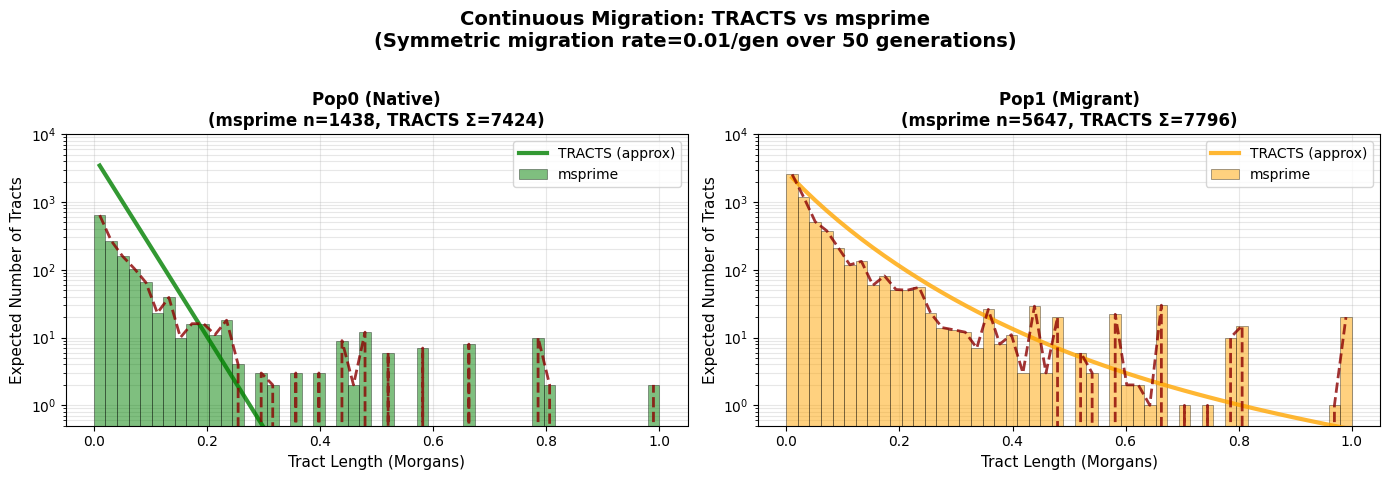


CONTINUOUS MIGRATION SUMMARY
Symmetric migration rate: 0.01/generation
Migration occurs from generation 2 to 50 (TRACTS constraint)
Founding split at generation 50: 50-50

Pop0 (native) tracts in Pop0 samples:
  msprime: n=1438, mean=0.0669 M
  TRACTS: Σ=7424

Pop1 (migrant) tracts in Pop0 samples:
  msprime: n=5647, mean=0.0637 M
  TRACTS: Σ=7796


In [9]:
# ============================================================================
# SCENARIO 2: CONTINUOUS MIGRATION (CORRECTED)
# Example: Ongoing gene flow between populations
# ============================================================================

# Parameters for continuous migration
t_start = 50  # Migration starts 50 generations ago
migration_rate = 0.01  # 1% per generation migration rate
Ne_cont = 10000
sample_size_cont = 200

# ============================================================================
# TRACTS: CONTINUOUS MIGRATION (CORRECTED)
# ============================================================================
def run_tracts_continuous():
    """
    Run TRACTS with continuous migration approximated as discrete pulses
    """
    if not HAS_TRACTS:
        return None, None
    
    # Approximate continuous migration with pulses every generation
    mig = np.zeros((t_start + 1, 2))  # Pop0, Pop1
    
    # FOUNDING EVENT (oldest, at index t_start) must sum to 1.0
    # At t=50, population splits 50-50 between two sources
    mig[t_start, 0] = 0.50
    mig[t_start, 1] = 0.50
    
    # Add small migration pulses each generation (continuous approximation)
    # IMPORTANT: TRACTS doesn't allow migration at generation 0 or 1
    # So we go from generation 2 to t_start-1
    for t in range(2, t_start):
        mig[t, 1] = migration_rate  # Migration from Pop1
    
    # Generation 0 and 1 must have no migration (TRACTS constraint)
    # mig[0, :] = 0  # Already zero
    # mig[1, :] = 0  # Already zero
    
    model = tracts.DemographicModel(mig)
    
    y0 = model.expectperbin(Ls, 0, bins)
    y1 = model.expectperbin(Ls, 1, bins)
    
    y0 = np.array(y0).flatten()[:len(bins)-1]
    y1 = np.array(y1).flatten()[:len(bins)-1]
    
    scaling_factor = 2 * sample_size_cont
    y0_scaled = y0 * scaling_factor
    y1_scaled = y1 * scaling_factor
    
    return y0_scaled, y1_scaled

# ============================================================================
# MSPRIME: CONTINUOUS MIGRATION (Native Support)
# ============================================================================
def run_msprime_continuous(rseed=43):
    """Run msprime with continuous symmetric migration"""
    
    demography = msprime.Demography()
    demography.add_population(name="Pop0", initial_size=Ne_cont)
    demography.add_population(name="Pop1", initial_size=Ne_cont)
    
    # Set symmetric continuous migration between populations
    # Migration happens from generation 0 up to t_start
    demography.set_migration_rate(source="Pop0", dest="Pop1", rate=migration_rate)
    demography.set_migration_rate(source="Pop1", dest="Pop0", rate=migration_rate)
    
    print("Running msprime continuous migration simulation...")
    
    ts = msprime.sim_ancestry(
        samples={"Pop0": sample_size_cont},  # Sample from Pop0
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=r,
        ploidy=2,
        model="dtwf",
        end_time=t_start,
        record_migrations=True,
        random_seed=rseed
    )
    
    print("Extracting tracts...")
    
    tables = ts.dump_tables()
    migrations = tables.migrations
    num_sample_nodes = 2 * sample_size_cont
    
    z = migrations.node[migrations.node >= num_sample_nodes]
    if z.size > 0:
        linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
    else:
        linked_edges = tskit.EdgeTable()
    
    ch_cache = defaultdict(list)
    for edge in linked_edges:
        ch_cache[edge.parent].append(edge)
    
    # Extract migration tracts
    tracts_by_pop = [[], []]  # Pop0, Pop1
    
    for row in migrations:
        if row.node < num_sample_nodes:
            seg_length = row.right - row.left
            tracts_by_pop[row.dest].append(seg_length)
        else:
            children = ch_cache[row.node]
            for child in children:
                seg_length = child.right - child.left
                tracts_by_pop[row.dest].append(seg_length)
    
    tracts_morgans = [np.array(t) / sequence_length for t in tracts_by_pop]
    
    return tracts_morgans[0], tracts_morgans[1]

# ============================================================================
# RUN AND PLOT CONTINUOUS MIGRATION
# ============================================================================

if HAS_TRACTS:
    print("Running TRACTS continuous migration model (approximated)...")
    tracts_pop0, tracts_pop1 = run_tracts_continuous()
else:
    tracts_pop0, tracts_pop1 = None, None

msprime_pop0, msprime_pop1 = run_msprime_continuous(rseed=43)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pop_labels = ['Pop0 (Native)', 'Pop1 (Migrant)']
colors = ['green', 'orange']
msprime_data_cont = [msprime_pop0, msprime_pop1]
tracts_data_cont = [tracts_pop0, tracts_pop1]

for idx, (ax, label, color, msp_tracts, tr_y) in enumerate(
    zip(axes, pop_labels, colors, msprime_data_cont, tracts_data_cont)):
    
    # msprime histogram
    if len(msp_tracts) > 0:
        counts, bin_edges = np.histogram(msp_tracts, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        ax.bar(bin_centers, counts, width=bin_width, 
               alpha=0.5, color=color, edgecolor='black', 
               linewidth=0.5, label='msprime', zorder=2)
        ax.plot(bin_centers, counts, color='darkred', 
                linestyle='--', linewidth=2, alpha=0.8, zorder=4)
    
    # TRACTS
    if HAS_TRACTS and tr_y is not None:
        bin_centers = (bins[:-1] + bins[1:]) / 2
        ax.plot(bin_centers, tr_y, color=color, linewidth=3, 
                label='TRACTS (approx)', alpha=0.8, linestyle='-', zorder=3)
    
    ax.set_yscale('log')
    ax.set_ylim([0.5, 1e4])
    ax.set_xlabel('Tract Length (Morgans)', fontsize=11)
    ax.set_ylabel('Expected Number of Tracts', fontsize=11)
    
    if HAS_TRACTS and tr_y is not None:
        title_str = f'{label}\n(msprime n={len(msp_tracts)}, TRACTS Σ={np.sum(tr_y):.0f})'
    else:
        title_str = f'{label}\n(n={len(msp_tracts)} tracts)'
    ax.set_title(title_str, fontsize=12, fontweight='bold')
    
    ax.grid(True, alpha=0.3, which='both', zorder=1)
    ax.legend(fontsize=10)

plt.suptitle(f'Continuous Migration: TRACTS vs msprime\n' + 
             f'(Symmetric migration rate={migration_rate}/gen over {t_start} generations)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig("continuous_migration_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("continuous_migration_comparison.pdf", bbox_inches='tight')
print("\nContinuous migration plots saved!")
plt.show()

# Statistics
print("\n" + "="*80)
print("CONTINUOUS MIGRATION SUMMARY")
print("="*80)
print(f"Symmetric migration rate: {migration_rate}/generation")
print(f"Migration occurs from generation 2 to {t_start} (TRACTS constraint)")
print(f"Founding split at generation {t_start}: 50-50")

print(f"\nPop0 (native) tracts in Pop0 samples:")
print(f"  msprime: n={len(msprime_pop0)}, mean={np.mean(msprime_pop0) if len(msprime_pop0)>0 else 0:.4f} M")
if HAS_TRACTS and tracts_pop0 is not None:
    print(f"  TRACTS: Σ={np.sum(tracts_pop0):.0f}")

print(f"\nPop1 (migrant) tracts in Pop0 samples:")
print(f"  msprime: n={len(msprime_pop1)}, mean={np.mean(msprime_pop1) if len(msprime_pop1)>0 else 0:.4f} M")
if HAS_TRACTS and tracts_pop1 is not None:
    print(f"  TRACTS: Σ={np.sum(tracts_pop1):.0f}")
print("="*80)

Running TRACTS Colombian model...
Running msprime Colombian simulation...
Extracting tracts...

Plots saved!


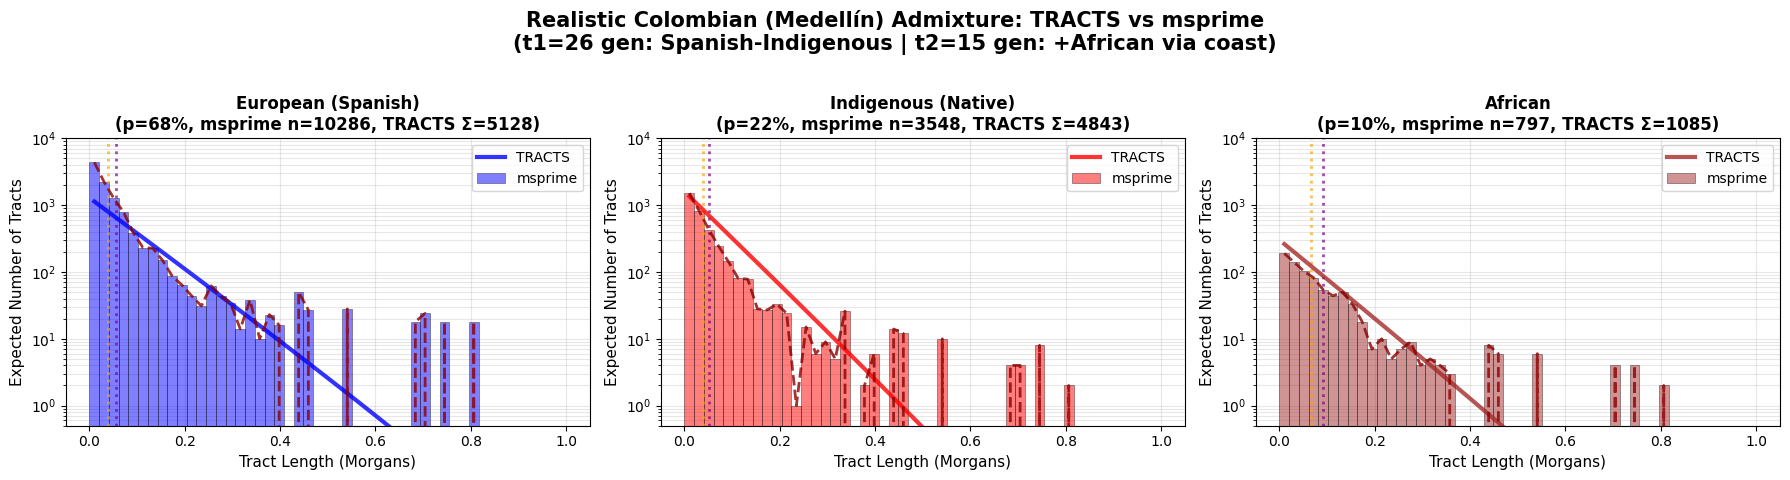


REALISTIC COLOMBIAN (MEDELLÍN) ADMIXTURE
Historical timeline:
  t1=26 gen (~1500 CE): Spanish conquest → European-Indigenous admixture
  t2=15 gen (~1700 CE): African slaves arrive via Pacific/Caribbean coast

Target ancestry proportions (matching 1000 Genomes):
  European: 68%
  Indigenous: 22%
  African: 10%

European (Spanish):
  msprime: n=10286 tracts, mean=0.0547 M
  TRACTS: Σ=5128 expected tracts
  Agreement: 0.50x
  Theoretical mean (1/26): 0.0385 M

Indigenous (Native):
  msprime: n=3548 tracts, mean=0.0513 M
  TRACTS: Σ=4843 expected tracts
  Agreement: 1.37x
  Theoretical mean (1/26): 0.0385 M

African:
  msprime: n=797 tracts, mean=0.0911 M
  TRACTS: Σ=1085 expected tracts
  Agreement: 1.36x
  Theoretical mean (1/15): 0.0667 M

NOTE: African tracts are shorter on average (more recent admixture)
      European/Indigenous tracts are longer (older admixture)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit
from collections import defaultdict

try:
    import tracts
    HAS_TRACTS = True
except ImportError:
    HAS_TRACTS = False

# ============================================================================
# REALISTIC COLOMBIAN (MEDELLÍN) 3-WAY ADMIXTURE
# Based on historical records and 1000 Genomes data
# ============================================================================

# Timeline (generations at ~20 years/gen)
t1 = 26  # ~1500 CE - Spanish conquest, immediate European-Indigenous admixture
t2 = 15  # ~1700 CE - Peak African slave trade to Colombia (via Cartagena/Pacific coast)

# Target proportions matching Medellín genomic data
p_european = 0.68    # 68% European
p_indigenous = 0.22  # 22% Indigenous  
p_african = 0.10     # 10% African

sequence_length = 1e8
r = 1e-8
Ne = 10000
sample_size = 200
bins = np.linspace(0, 1, 50)
Ls = [1.0]

# ============================================================================
# TRACTS: REALISTIC COLOMBIAN MODEL
# ============================================================================
def run_tracts_colombian_realistic():
    """
    Realistic Colombian (Medellín) admixture:
    - t1=26 gen: Spanish-Indigenous contact (founding event)
    - t2=15 gen: African admixture arrives (smaller proportion in interior)
    """
    if not HAS_TRACTS:
        return None, None, None
    
    mig = np.zeros((t1 + 1, 3))  # 0=European, 1=Indigenous, 2=African
    
    # FOUNDING EVENT at t1=26: Spanish conquest
    # Initial admixture was primarily Spanish men + Indigenous women
    # Start with roughly equal proportions, then adjust
    mig[t1, 0] = 0.58  # European (Spanish colonizers)
    mig[t1, 1] = 0.42  # Indigenous (native populations)
    # No African yet
    
    # t2=15 gen: African slaves arrive via coast
    # In Medellín (interior), African admixture is lower than coastal regions
    # This pulse adds ~10% African ancestry
    mig[t2, 2] = 0.10
    
    model = tracts.DemographicModel(mig)
    
    y_eur = np.array(model.expectperbin(Ls, 0, bins)).flatten()[:len(bins)-1]
    y_ind = np.array(model.expectperbin(Ls, 1, bins)).flatten()[:len(bins)-1]
    y_afr = np.array(model.expectperbin(Ls, 2, bins)).flatten()[:len(bins)-1]
    
    scaling_factor = 2 * sample_size
    
    return (y_eur * scaling_factor, 
            y_ind * scaling_factor, 
            y_afr * scaling_factor)

# ============================================================================
# MSPRIME: REALISTIC COLOMBIAN MODEL
# ============================================================================
def run_msprime_colombian_realistic(rseed=42):
    """
    msprime simulation matching Colombian history
    """
    
    demography = msprime.Demography()
    demography.add_population(name="Adm", initial_size=Ne)      # Admixed (present-day Colombians)
    demography.add_population(name="European", initial_size=Ne) # Spanish
    demography.add_population(name="Indigenous", initial_size=Ne)
    demography.add_population(name="African", initial_size=Ne)
    
    # t2=15 gen ago: African admixture (10%)
    demography.add_mass_migration(time=t2, source="Adm", dest="African", proportion=p_african)
    
    # t1=26 gen ago: Founding admixture (Spanish + Indigenous)
    # Remaining ancestry after African contribution splits between European and Indigenous
    remaining = 1.0 - p_african  # 0.90
    prop_eur_at_t1 = p_european / remaining  # 0.68/0.90 = 0.756
    prop_ind_at_t1 = p_indigenous / remaining # 0.22/0.90 = 0.244
    
    demography.add_mass_migration(time=t1, source="Adm", dest="European", proportion=prop_eur_at_t1)
    demography.add_mass_migration(time=t1, source="Adm", dest="Indigenous", proportion=1.0)
    
    print("Running msprime Colombian simulation...")
    
    ts = msprime.sim_ancestry(
        samples={"Adm": sample_size},
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=r,
        ploidy=2,
        model="dtwf",
        end_time=t1+1,
        record_migrations=True,
        random_seed=rseed
    )
    
    print("Extracting tracts...")
    
    tables = ts.dump_tables()
    migrations = tables.migrations
    num_sample_nodes = 2 * sample_size
    
    z = migrations.node[migrations.node >= num_sample_nodes]
    if z.size > 0:
        linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
    else:
        linked_edges = tskit.EdgeTable()
    
    ch_cache = defaultdict(list)
    for edge in linked_edges:
        ch_cache[edge.parent].append(edge)
    
    # Extract tracts: 0=Adm, 1=European, 2=Indigenous, 3=African
    tracts = [[], [], [], []]
    for row in migrations:
        if row.node < num_sample_nodes:
            seg_length = row.right - row.left
            tracts[row.dest].append(seg_length)
        else:
            children = ch_cache[row.node]
            for child in children:
                seg_length = child.right - child.left
                tracts[row.dest].append(seg_length)
    
    tracts_morgans = [np.array(t) / sequence_length for t in tracts]
    
    return tracts_morgans[1], tracts_morgans[2], tracts_morgans[3]

# ============================================================================
# RUN AND PLOT
# ============================================================================

if HAS_TRACTS:
    print("Running TRACTS Colombian model...")
    tracts_eur, tracts_ind, tracts_afr = run_tracts_colombian_realistic()
else:
    tracts_eur, tracts_ind, tracts_afr = None, None, None

msprime_eur, msprime_ind, msprime_afr = run_msprime_colombian_realistic(rseed=42)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pop_labels = ['European (Spanish)', 'Indigenous (Native)', 'African']
colors = ['blue', 'red', 'brown']
msprime_data = [msprime_eur, msprime_ind, msprime_afr]
tracts_data = [tracts_eur, tracts_ind, tracts_afr]
final_props = [p_european, p_indigenous, p_african]

for idx, (ax, label, color, msp_tracts, tr_y, prop) in enumerate(
    zip(axes, pop_labels, colors, msprime_data, tracts_data, final_props)):
    
    # msprime histogram
    if len(msp_tracts) > 0:
        counts, bin_edges = np.histogram(msp_tracts, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        ax.bar(bin_centers, counts, width=bin_width, 
               alpha=0.5, color=color, edgecolor='black', 
               linewidth=0.5, label='msprime', zorder=2)
        ax.plot(bin_centers, counts, color='darkred', 
                linestyle='--', linewidth=2, alpha=0.8, zorder=4)
    
    # TRACTS
    if HAS_TRACTS and tr_y is not None:
        bin_centers = (bins[:-1] + bins[1:]) / 2
        ax.plot(bin_centers, tr_y, color=color, linewidth=3, 
                label='TRACTS', alpha=0.8, linestyle='-', zorder=3)
    
    ax.set_yscale('log')
    ax.set_ylim([0.5, 1e4])
    ax.set_xlabel('Tract Length (Morgans)', fontsize=11)
    ax.set_ylabel('Expected Number of Tracts', fontsize=11)
    
    if HAS_TRACTS and tr_y is not None:
        title_str = f'{label}\n(p={prop:.0%}, msprime n={len(msp_tracts)}, TRACTS Σ={np.sum(tr_y):.0f})'
    else:
        title_str = f'{label}\n(p={prop:.0%}, n={len(msp_tracts)} tracts)'
    ax.set_title(title_str, fontsize=12, fontweight='bold')
    
    ax.grid(True, alpha=0.3, which='both', zorder=1)
    ax.legend(fontsize=10)
    
    # Add mean lines
    if idx == 0 or idx == 1:  # European and Indigenous from t1
        theoretical_mean = 1.0 / t1
    else:  # African from t2
        theoretical_mean = 1.0 / t2
    
    if len(msp_tracts) > 0:
        ax.axvline(np.mean(msp_tracts), color='purple', linestyle=':', 
                   linewidth=2, alpha=0.7, 
                   label=f'msprime μ={np.mean(msp_tracts):.3f}')
        ax.axvline(theoretical_mean, color='orange', linestyle=':', 
                   linewidth=2, alpha=0.7,
                   label=f'theory μ={theoretical_mean:.3f}')

plt.suptitle('Realistic Colombian (Medellín) Admixture: TRACTS vs msprime\n' + 
             f'(t1={t1} gen: Spanish-Indigenous | t2={t2} gen: +African via coast)',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

plt.savefig("colombian_realistic_3way_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("colombian_realistic_3way_comparison.pdf", bbox_inches='tight')
print("\nPlots saved!")
plt.show()

# Statistics
print("\n" + "="*80)
print("REALISTIC COLOMBIAN (MEDELLÍN) ADMIXTURE")
print("="*80)
print(f"Historical timeline:")
print(f"  t1={t1} gen (~1500 CE): Spanish conquest → European-Indigenous admixture")
print(f"  t2={t2} gen (~1700 CE): African slaves arrive via Pacific/Caribbean coast")
print(f"\nTarget ancestry proportions (matching 1000 Genomes):")
print(f"  European: {p_european:.0%}")
print(f"  Indigenous: {p_indigenous:.0%}")
print(f"  African: {p_african:.0%}")

for idx, (label, msp_tracts, tr_y) in enumerate(zip(
    pop_labels, msprime_data, 
    [tracts_eur, tracts_ind, tracts_afr] if HAS_TRACTS else [None]*3)):
    
    print(f"\n{label}:")
    print(f"  msprime: n={len(msp_tracts)} tracts, mean={np.mean(msp_tracts):.4f} M")
    if HAS_TRACTS and tr_y is not None:
        print(f"  TRACTS: Σ={np.sum(tr_y):.0f} expected tracts")
        if len(msp_tracts) > 0:
            print(f"  Agreement: {np.sum(tr_y)/len(msp_tracts):.2f}x")
    
    if idx in [0, 1]:
        print(f"  Theoretical mean (1/{t1}): {1.0/t1:.4f} M")
    else:
        print(f"  Theoretical mean (1/{t2}): {1.0/t2:.4f} M")

print("\n" + "="*80)
print("NOTE: African tracts are shorter on average (more recent admixture)")
print("      European/Indigenous tracts are longer (older admixture)")
print("="*80)

In [2]:
import msprime
print(msprime.__version__)

1.3.4
